In [82]:
import torch
torch.__version__

'2.5.1'

In [83]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


1. Compute the gradient for the function y = 8x^4 + 3x^3 + 7x^2 + 6x + 3 and verify the gradients
provided by PyTorch with the analytical gradients.

In [84]:
x = torch.tensor([2.0], device=device,  requires_grad=True)
y = (8 * x ** 4) + (3 * x ** 3) + (7 * x ** 2) + (6 * x) + 3
y.backward()

print("PyTorch computed Grad : ", x.grad.item())
print("Analytical Grad : ", ((32 * x.item() ** 3) + (9 * x.item() ** 2) + (14 * x.item()) + 6))

PyTorch computed Grad :  326.0
Analytical Grad :  326.0


2. For the following training data, build a linear regression model. Assume w and b are initialized with 1, and the learning rate is set to 0.001.

Epoch 1: w = 0.8826, b = 0.9935, loss = 11.5443
Epoch 6: w = 0.8143, b = 0.9898, loss = 0.5824
Epoch 11: w = 0.8138, b = 0.9898, loss = 0.5819
Epoch 16: w = 0.8138, b = 0.9900, loss = 0.5819
Epoch 21: w = 0.8138, b = 0.9901, loss = 0.5819
Epoch 26: w = 0.8138, b = 0.9902, loss = 0.5819
Epoch 31: w = 0.8138, b = 0.9903, loss = 0.5819
Epoch 36: w = 0.8138, b = 0.9904, loss = 0.5819
Epoch 41: w = 0.8138, b = 0.9905, loss = 0.5819
Epoch 46: w = 0.8138, b = 0.9906, loss = 0.5819
Epoch 51: w = 0.8138, b = 0.9907, loss = 0.5819
Epoch 56: w = 0.8138, b = 0.9909, loss = 0.5819
Epoch 61: w = 0.8138, b = 0.9910, loss = 0.5819
Epoch 66: w = 0.8138, b = 0.9911, loss = 0.5819
Epoch 71: w = 0.8138, b = 0.9912, loss = 0.5819
Epoch 76: w = 0.8138, b = 0.9913, loss = 0.5819
Epoch 81: w = 0.8138, b = 0.9914, loss = 0.5819
Epoch 86: w = 0.8137, b = 0.9915, loss = 0.5819
Epoch 91: w = 0.8137, b = 0.9917, loss = 0.5819
Epoch 96: w = 0.8137, b = 0.9918, loss = 0.5819


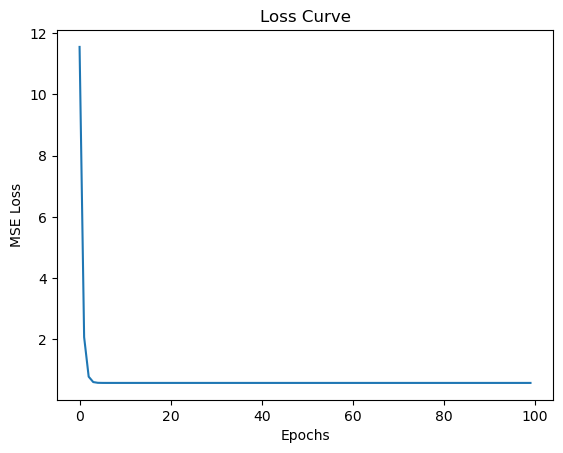

In [85]:
import matplotlib.pyplot as plt

x = torch.tensor(
        [
            12.4, 14.3, 14.5, 14.9, 16.1, 16.9, 16.5, 15.4, 17.0, 17.9, 18.8, 20.3,
            22.4, 19.4, 19.4, 15.7, 16.7, 17.3, 18.4, 19.4, 19.5, 19.7, 21.2
        ]
    , device=device, dtype=torch.float32)

y = torch.tensor(
        [
            11.2, 12.5, 12.7, 13.1, 14.1, 14.8, 14.4, 13.4, 14.9, 15.6, 16.4, 17.7,
            19.6, 16.9, 14.0, 14.6, 15.1, 16.1, 16.8, 15.2, 17.0, 17.2, 18.6
        ]
    , device=device, dtype=torch.float32)

w = torch.tensor([1.0], device=device, requires_grad=True)
b = torch.tensor([1.0], device=device, requires_grad=True)

epochs = 100

losses = []

for epoch in range(epochs):
    y_pred = w * x + b
    loss = torch.mean((y - y_pred) ** 2)

    losses.append(loss.item())

    loss.backward()

    with torch.no_grad():
        w -= 0.001 * w.grad
        b -= 0.001 * b.grad

        w.grad.zero_()
        b.grad.zero_()

    if epoch % 5 == 0:
        print(f"Epoch {epoch+1}: w = {w.item():.4f}, b = {b.item():.4f}, loss = {loss.item():.4f}")

plt.plot(range(epochs), losses)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Loss Curve")
plt.show()

Extend the code to use the California Housing Dataset.

Epoch 1: loss = 7.8781
Epoch 21: loss = 3.4067
Epoch 41: loss = 1.9501
Epoch 61: loss = 1.3851
Epoch 81: loss = 1.1316
Epoch 101: loss = 1.0036
Epoch 121: loss = 0.9318
Epoch 141: loss = 0.8868
Epoch 161: loss = 0.8556
Epoch 181: loss = 0.8316
Epoch 201: loss = 0.8119
Epoch 221: loss = 0.7948
Epoch 241: loss = 0.7794
Epoch 261: loss = 0.7654
Epoch 281: loss = 0.7524
Epoch 301: loss = 0.7402
Epoch 321: loss = 0.7288
Epoch 341: loss = 0.7181
Epoch 361: loss = 0.7080
Epoch 381: loss = 0.6985
Epoch 401: loss = 0.6895
Epoch 421: loss = 0.6810
Epoch 441: loss = 0.6730
Epoch 461: loss = 0.6654
Epoch 481: loss = 0.6582
Predicted house value for given features: 2.5639 (in 100,000s USD)


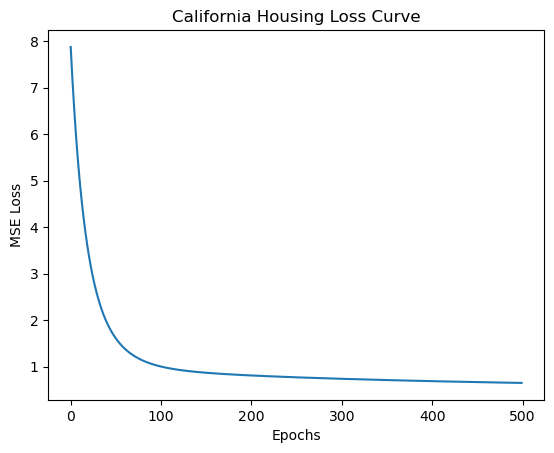

In [86]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

data = fetch_california_housing()
housing_features = torch.tensor(data.data, device=device, dtype=torch.float32)
housing_targets = torch.tensor(data.target, device=device, dtype=torch.float32).view(-1,1)
# print(housing_features.shape, housing_targets.view(-1,1).shape)
# print(housing_features)
# print(housing_targets)

scaler = StandardScaler()
housing_features = torch.tensor(scaler.fit_transform(housing_features.cpu()), device=device, dtype=torch.float32)
# print(housing_features.shape)
# print(housing_features)

weights = torch.ones((housing_features.shape[1], 1), device=device, dtype=torch.float32, requires_grad=True)
bias = torch.tensor([1.0], device=device, dtype=torch.float32, requires_grad=True)
# print(weights.shape)
# print(bias.shape)

ephocs = 500
losses_california_housing = []

for epoch in range(ephocs):
    y_pred = housing_features.mm(weights) + bias
    loss = torch.mean((housing_targets - y_pred) ** 2)

    losses_california_housing.append(loss.item())

    loss.backward()

    with torch.no_grad():
        weights -= 0.01 * weights.grad
        bias -= 0.01 * bias.grad

        weights.grad.zero_()
        bias.grad.zero_()

    if epoch % 20 == 0:
        print(f"Epoch {epoch+1}: loss = {loss.item():.4f}")

with torch.no_grad():
    prediction_input = torch.tensor([[
                        5.0,   # MedInc
                        25.0,  # HouseAge
                        5.5,   # AveRooms
                        1.1,   # AveBedrms
                        1000.0,# Population
                        3.0,   # AveOccup
                        34.0,  # Latitude
                        -118.0 # Longitude
                    ]], device=device, dtype=torch.float32)
    prediction_input_scaled = torch.tensor(scaler.transform(prediction_input.cpu()), device=device, dtype=torch.float32)
    prediction = prediction_input_scaled.mm(weights) + bias

print(f"Predicted house value for given features: {prediction.item():.4f} (in 100,000s USD)")

plt.plot(range(ephocs), losses_california_housing)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("California Housing Loss Curve")
plt.show()

3. Implement logistic regression

In [87]:
x = torch.tensor([1, 5, 10, 10, 25, 50, 70, 75, 100], device=device, dtype=torch.float32)
y = torch.tensor([0, 0, 0, 0, 0, 1, 1, 1, 1], device=device, dtype=torch.float32)

w = torch.tensor([1.0], device=device, dtype=torch.float32, requires_grad=True)
b = torch.tensor([1.0], device=device, dtype=torch.float32, requires_grad=True)

def sigmoid(z):
    return 1 / (1 + torch.exp(-z))

loss_fn = torch.nn.BCEWithLogitsLoss()

for epoch in range(100):
    z = x * w + b
    y_pred = sigmoid(z)
    loss = loss_fn(y_pred, y)

    loss.backward()

    with torch.no_grad():
        w -= 0.01 * w.grad
        b -= 0.01 * b.grad

        w.grad.zero_()
        b.grad.zero_()

    if epoch % 5  == 0:
        print(f"Epoch {epoch+1}: loss = {loss.item():.4f}")

Epoch 1: loss = 0.8591
Epoch 6: loss = 0.8591
Epoch 11: loss = 0.8591
Epoch 16: loss = 0.8591
Epoch 21: loss = 0.8591
Epoch 26: loss = 0.8590
Epoch 31: loss = 0.8590
Epoch 36: loss = 0.8590
Epoch 41: loss = 0.8590
Epoch 46: loss = 0.8590
Epoch 51: loss = 0.8590
Epoch 56: loss = 0.8590
Epoch 61: loss = 0.8590
Epoch 66: loss = 0.8590
Epoch 71: loss = 0.8590
Epoch 76: loss = 0.8590
Epoch 81: loss = 0.8590
Epoch 86: loss = 0.8590
Epoch 91: loss = 0.8589
Epoch 96: loss = 0.8589


4. Implement two layer Feed Forward Neural Network for XOR Logic Gate with 2-bit Binary Input using Sigmoid activation. Verify the number of learnable parameters in the model.

In [105]:
x = torch.tensor(
    [
        [0., 0.],
        [1., 0.],
        [0., 1.],
        [1., 1.]
    ], device=device, dtype=torch.float32)

y = torch.tensor(
    [
        [0.],
        [1.],
        [1.],
        [0.]
    ], device=device, dtype=torch.float32)

class XORNet(torch.nn.Module):
    def __init__(self):
        super(XORNet, self).__init__()
        self.hidden = torch.nn.Linear(2, 2)
        self.output = torch.nn.Linear(2, 1)

    def forward(self, x):
        x = torch.sigmoid(self.hidden(x))
        x = torch.sigmoid(self.output(x))
        return x

model = XORNet().to(device)
loss_fn = torch.nn.BCELoss()

# for name, param in model.named_parameters():
#     print(name, " : " , param)


optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

for epoch in range(10000):
    y_pred = model(x)
    loss = loss_fn(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch+1}: loss = {loss.item():.4f}")

with torch.no_grad():
    prediction = model(x)
    print("Predictions : ", prediction)

Epoch 1: loss = 0.6933
Epoch 501: loss = 0.6931
Epoch 1001: loss = 0.6931
Epoch 1501: loss = 0.6931
Epoch 2001: loss = 0.6931
Epoch 2501: loss = 0.6931
Epoch 3001: loss = 0.6930
Epoch 3501: loss = 0.6929
Epoch 4001: loss = 0.6927
Epoch 4501: loss = 0.6922
Epoch 5001: loss = 0.6907
Epoch 5501: loss = 0.6851
Epoch 6001: loss = 0.6667
Epoch 6501: loss = 0.6229
Epoch 7001: loss = 0.5684
Epoch 7501: loss = 0.5270
Epoch 8001: loss = 0.4813
Epoch 8501: loss = 0.3973
Epoch 9001: loss = 0.2619
Epoch 9501: loss = 0.1561
Predictions :  tensor([[0.0533],
        [0.9144],
        [0.9144],
        [0.1555]], device='cuda:0')


Implement Feed Forward Neural Network with two hidden layers for classifying handwritten digits using the MNIST dataset. Display the classification accuracy in the form of a Confusion matrix. Verify the number of learnable parameters in the model.